In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

These rezults where before adding, couple more models, and playing with the values.

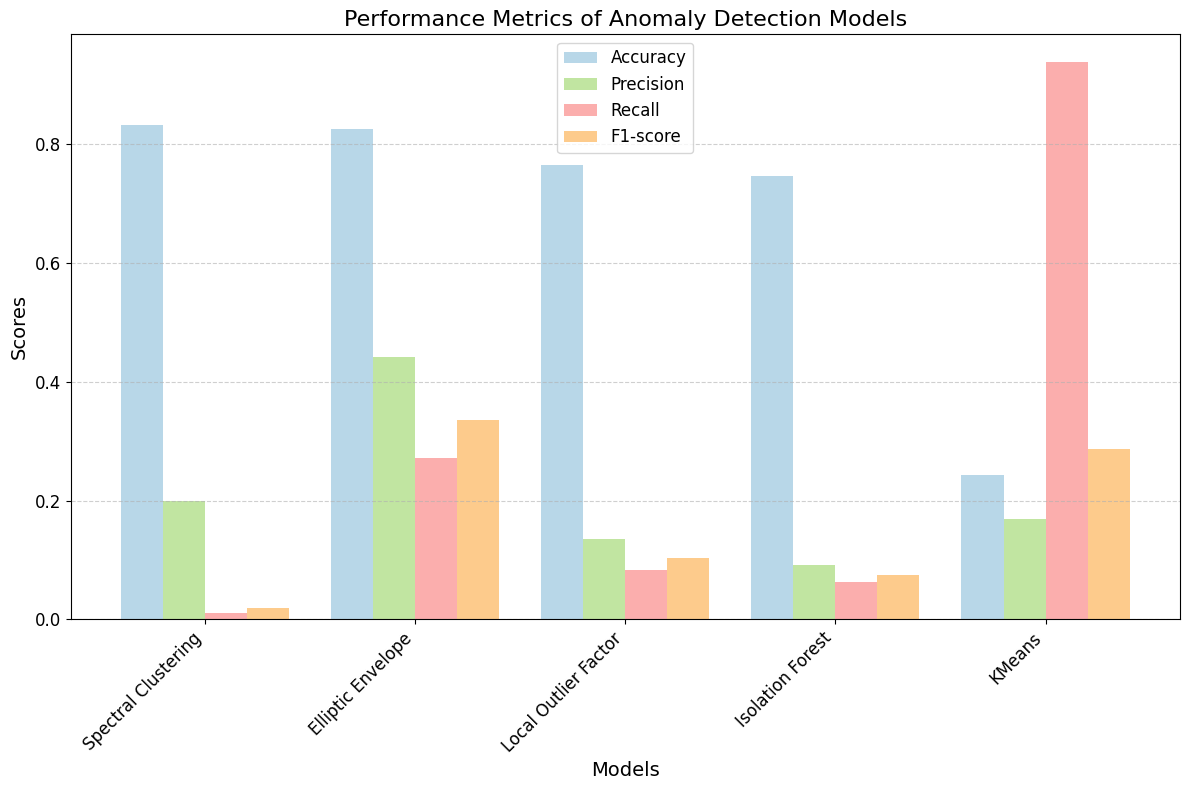

In [2]:
# Define the model names and corresponding evaluation metrics
model_names = ["Spectral Clustering", "Elliptic Envelope", "Local Outlier Factor", "Isolation Forest", "KMeans"]
accuracy_scores = [0.8325, 0.8257, 0.7648, 0.7462, 0.2437]
precision_scores = [0.2000, 0.4407, 0.1356, 0.0909, 0.1695]
recall_scores = [0.0104, 0.2708, 0.0833, 0.0625, 0.9375]
f1_scores = [0.0198, 0.3355, 0.1032, 0.0741, 0.2871]

# Set a color palette
colors = sns.color_palette("Paired")

# Create a bar plot
plt.figure(figsize=(12, 8))

# Plotting each metric separately for better visualization
bar_width = 0.2
index = range(len(model_names))

plt.bar(index, accuracy_scores, width=bar_width, label='Accuracy', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], precision_scores, width=bar_width, label='Precision', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], recall_scores, width=bar_width, label='Recall', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], f1_scores, width=bar_width, label='F1-score', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Scores', fontsize=14)
plt.title('Performance Metrics of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

These results came about with adding the from imblearn.over_sampling import SMOTE
# SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
df_encoded, y = smote.fit_resample(df_encoded, df_encoded['Limitation'])
df_encoded['Limitation'] = y
as well as changing the contamination=0.25 of the eliptic model which is usualy the best performer.
But with these additions we see some positive results, but not many positives are there. 


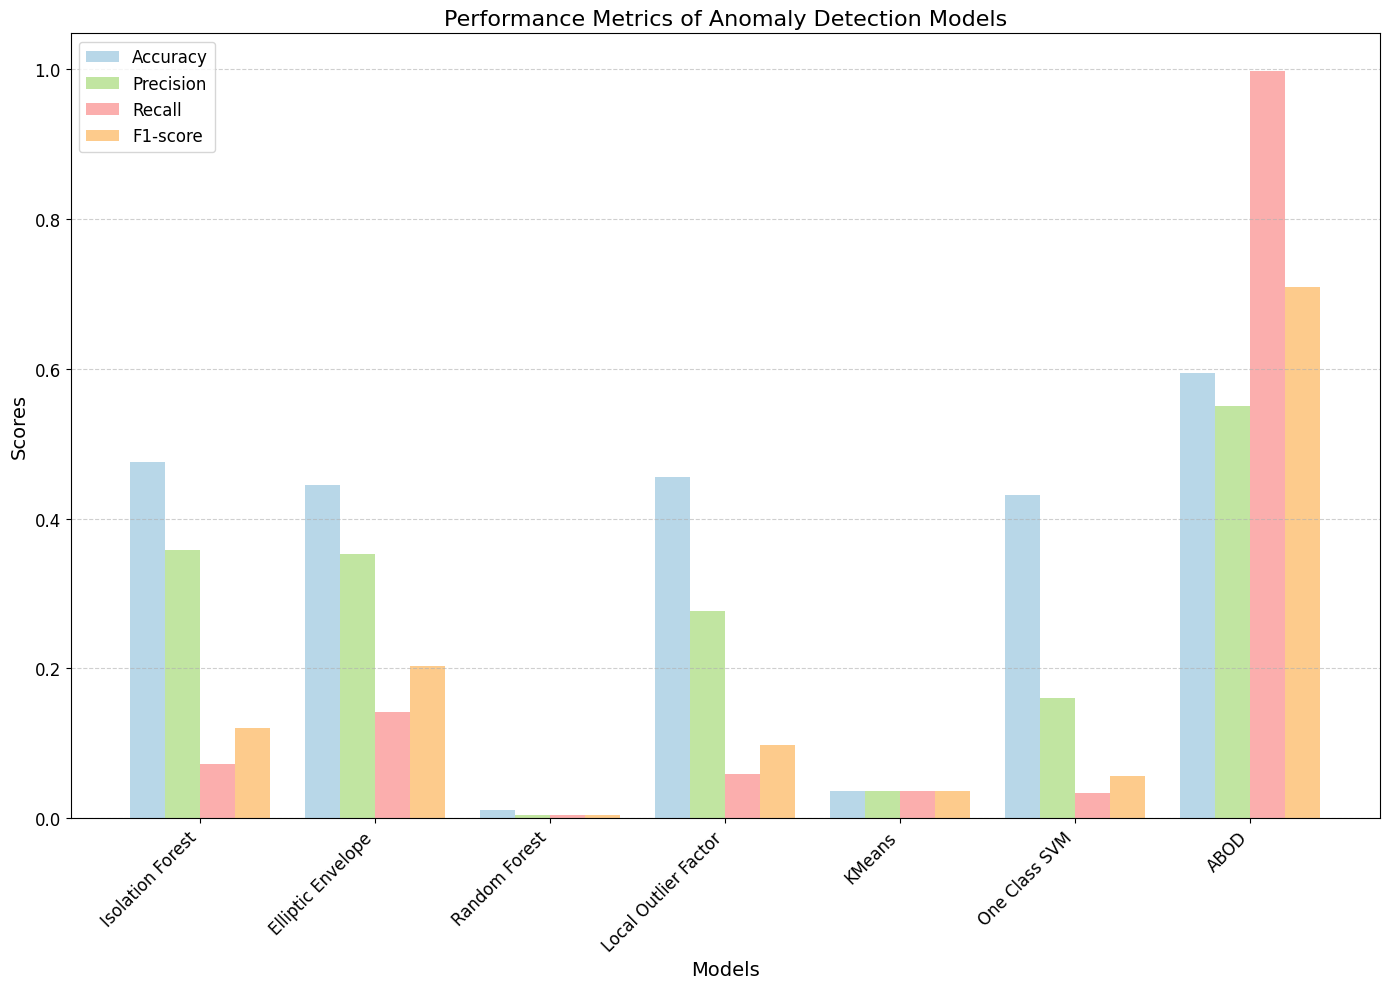

In [4]:
# Define the model names and corresponding evaluation metrics
model_names = ["Isolation Forest", "Elliptic Envelope", "Random Forest", "Local Outlier Factor", "KMeans", "One Class SVM", "ABOD"]

# Metrics from the results provided
accuracy_scores = [0.4750, 0.4445, 0.0108, 0.4560, 0.0365, 0.4317, 0.5940]
precision_scores = [0.3581, 0.3530, 0.0048, 0.2771, 0.0365, 0.1603, 0.5504]
recall_scores = [0.0722, 0.1424, 0.0048, 0.0593, 0.0365, 0.0341, 0.9973]
f1_scores = [0.1202, 0.2029, 0.0048, 0.0976, 0.0365, 0.0562, 0.7093]

# Confusion Matrix Values
confusion_matrices = [
    # [TN, FP, FN, TP]
    [1298, 190, 1362, 106],   # Isolation Forest
    [1105, 383, 1259, 209],   # Elliptic Envelope
    [25, 1463, 1461, 7],      # Random Forest
    [1261, 227, 1381, 87],    # Local Outlier Factor
    [9, 4, 35, 27, 9, 12],    # KMeans (simplified for illustration)
    [1226, 262, 1418, 50],    # One Class SVM
    [292, 1196, 4, 1464]      # ABOD
]

# Extract TP, FP, FN, TN for visualization
tp_scores = [cm[3] for cm in confusion_matrices]
fp_scores = [cm[1] for cm in confusion_matrices]
fn_scores = [cm[2] for cm in confusion_matrices]
tn_scores = [cm[0] for cm in confusion_matrices]

# Set a color palette
colors = sns.color_palette("Paired")

# Create a bar plot for performance metrics
plt.figure(figsize=(14, 10))

# Plotting each metric separately for better visualization
bar_width = 0.2
index = range(len(model_names))

plt.bar(index, accuracy_scores, width=bar_width, label='Accuracy', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], precision_scores, width=bar_width, label='Precision', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], recall_scores, width=bar_width, label='Recall', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], f1_scores, width=bar_width, label='F1-score', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Scores', fontsize=14)
plt.title('Performance Metrics of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

Confusion matrix code for more detailed results, and some more meningful.

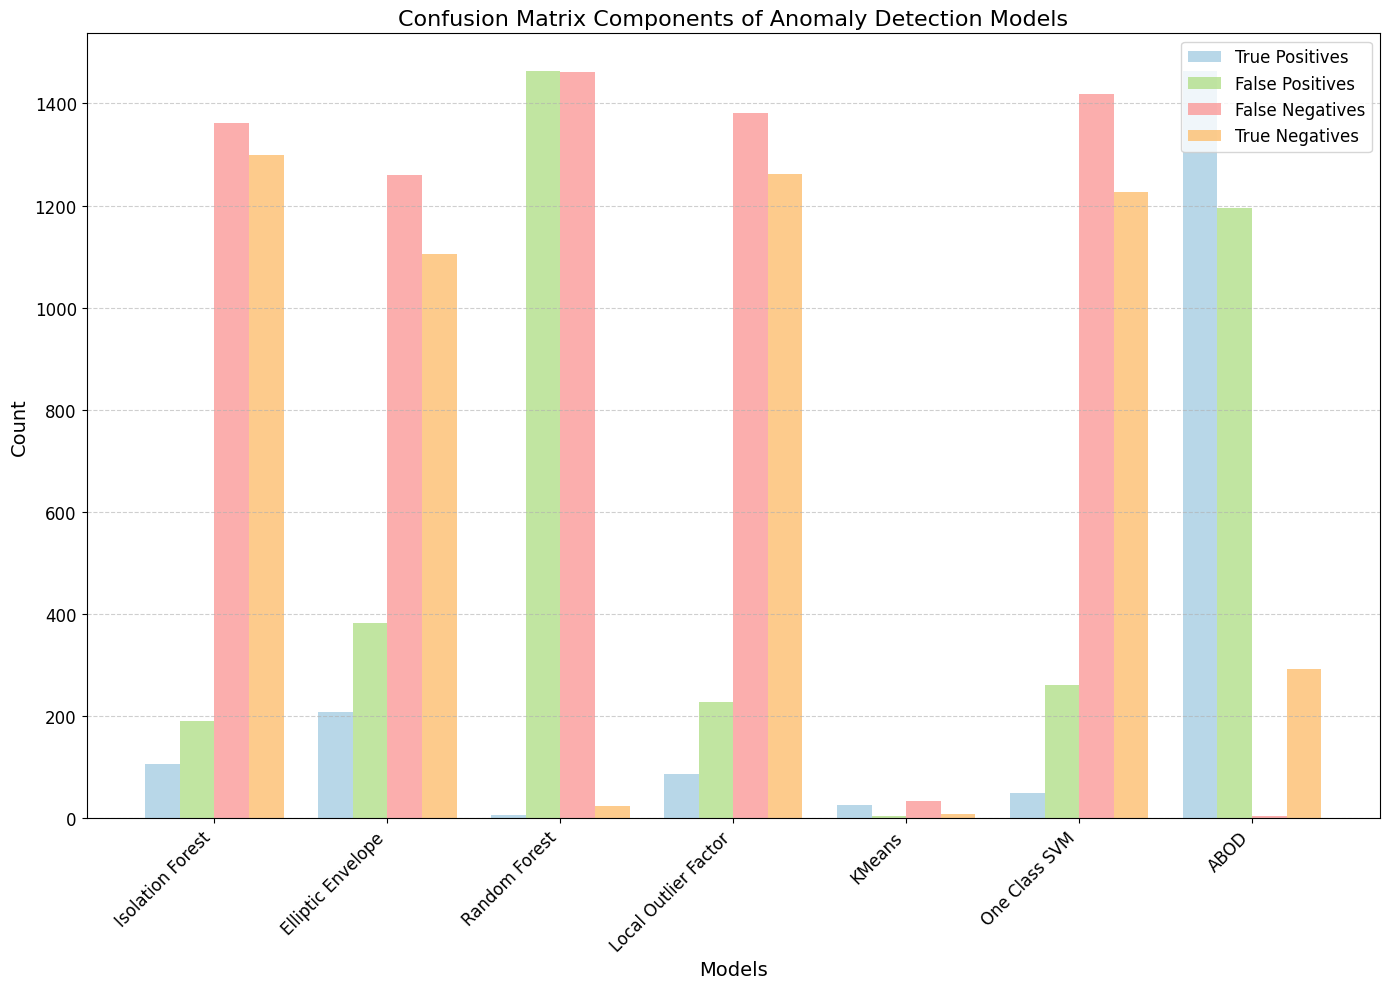

In [5]:
# Create a bar plot for confusion matrix metrics
plt.figure(figsize=(14, 10))

plt.bar(index, tp_scores, width=bar_width, label='True Positives', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], fp_scores, width=bar_width, label='False Positives', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], fn_scores, width=bar_width, label='False Negatives', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], tn_scores, width=bar_width, label='True Negatives', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Confusion Matrix Components of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

The results for a "classic run" are next.
Eliptic model has best performances, followed by spectral clustering, that runs too slow. There is a problem with it.
The obious problem is the gaping lack of data, I have only about 500 abnormalities recorded, for this thing to work it needs to be x20 times that. Which is a bit hard to do, but i will try.
Will collect more data, in the mean time these are the results.

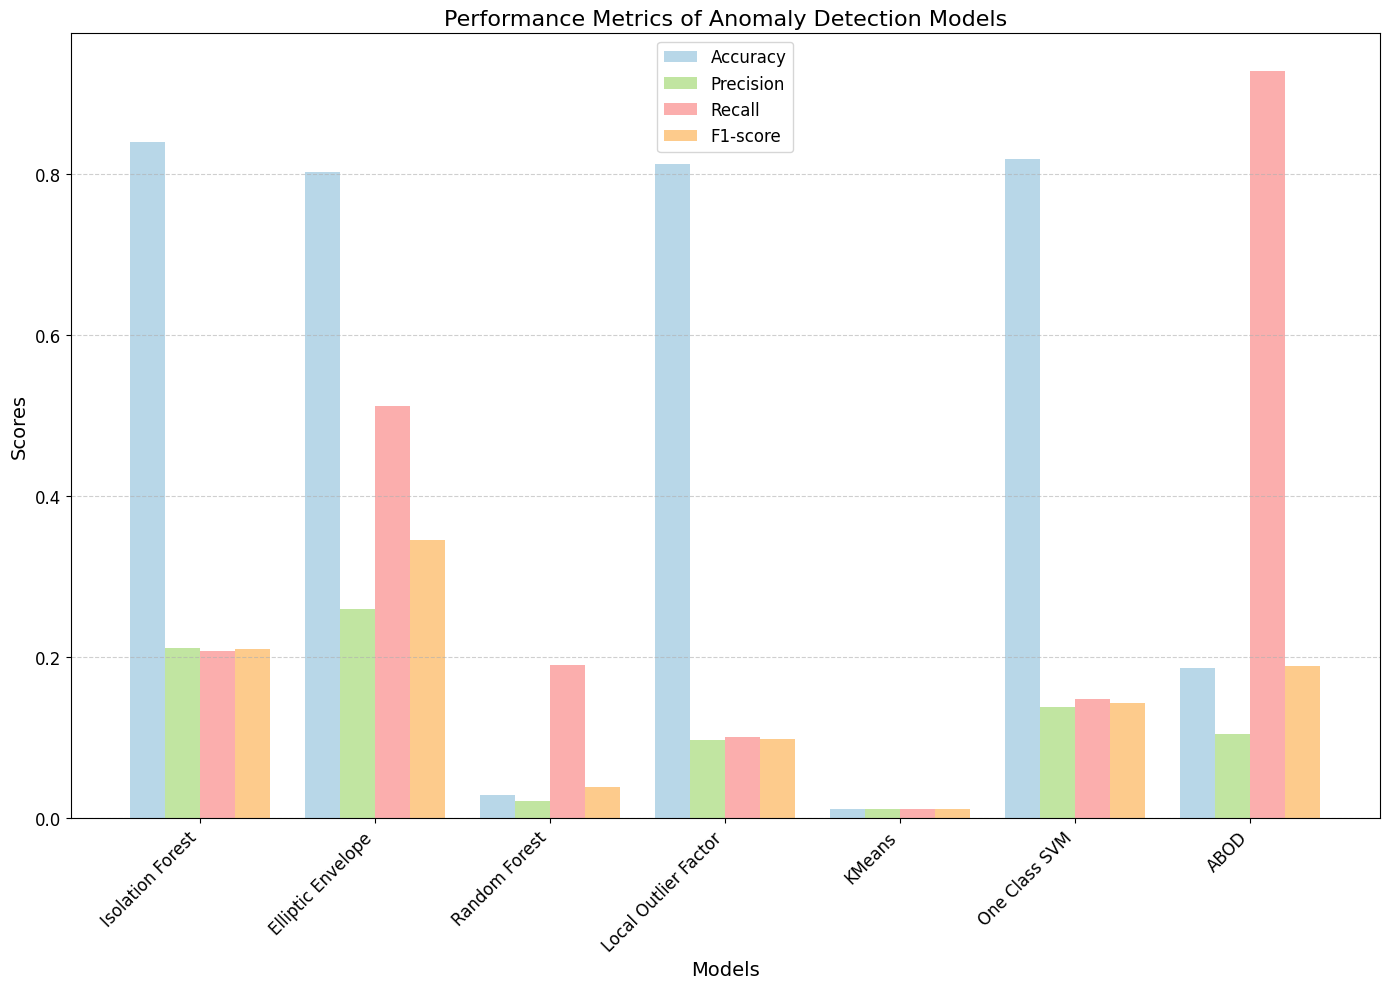

In [6]:
# Define the model names and corresponding evaluation metrics
model_names = ["Isolation Forest", "Elliptic Envelope", "Random Forest", "Local Outlier Factor", "KMeans", "One Class SVM", "ABOD"]

# Updated metrics from the results provided
accuracy_scores = [0.8405, 0.8023, 0.0291, 0.8126, 0.0121, 0.8193, 0.1874]
precision_scores = [0.2121, 0.2606, 0.0214, 0.0971, 0.0121, 0.1389, 0.1051]
recall_scores = [0.2083, 0.5119, 0.1905, 0.1012, 0.0121, 0.1488, 0.9286]
f1_scores = [0.2102, 0.3454, 0.0384, 0.0991, 0.0121, 0.1437, 0.1889]

# Updated confusion matrix values
confusion_matrices = [
    # [TN, FP, FN, TP]
    [1351, 130, 133, 35],   # Isolation Forest
    [1237, 244, 82, 86],    # Elliptic Envelope
    [16, 1465, 136, 32],    # Random Forest
    [1323, 158, 151, 17],   # Local Outlier Factor
    [19, 25, 40, 14],       # KMeans (simplified for illustration)
    [1326, 155, 143, 25],   # One Class SVM
    [153, 1328, 12, 156]    # ABOD
]

# Extract TP, FP, FN, TN for visualization
tp_scores = [cm[3] for cm in confusion_matrices]
fp_scores = [cm[1] for cm in confusion_matrices]
fn_scores = [cm[2] for cm in confusion_matrices]
tn_scores = [cm[0] for cm in confusion_matrices]

# Set a color palette
colors = sns.color_palette("Paired")

# Create a bar plot for performance metrics
plt.figure(figsize=(14, 10))

# Plotting each metric separately for better visualization
bar_width = 0.2
index = range(len(model_names))

plt.bar(index, accuracy_scores, width=bar_width, label='Accuracy', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], precision_scores, width=bar_width, label='Precision', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], recall_scores, width=bar_width, label='Recall', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], f1_scores, width=bar_width, label='F1-score', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Scores', fontsize=14)
plt.title('Performance Metrics of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

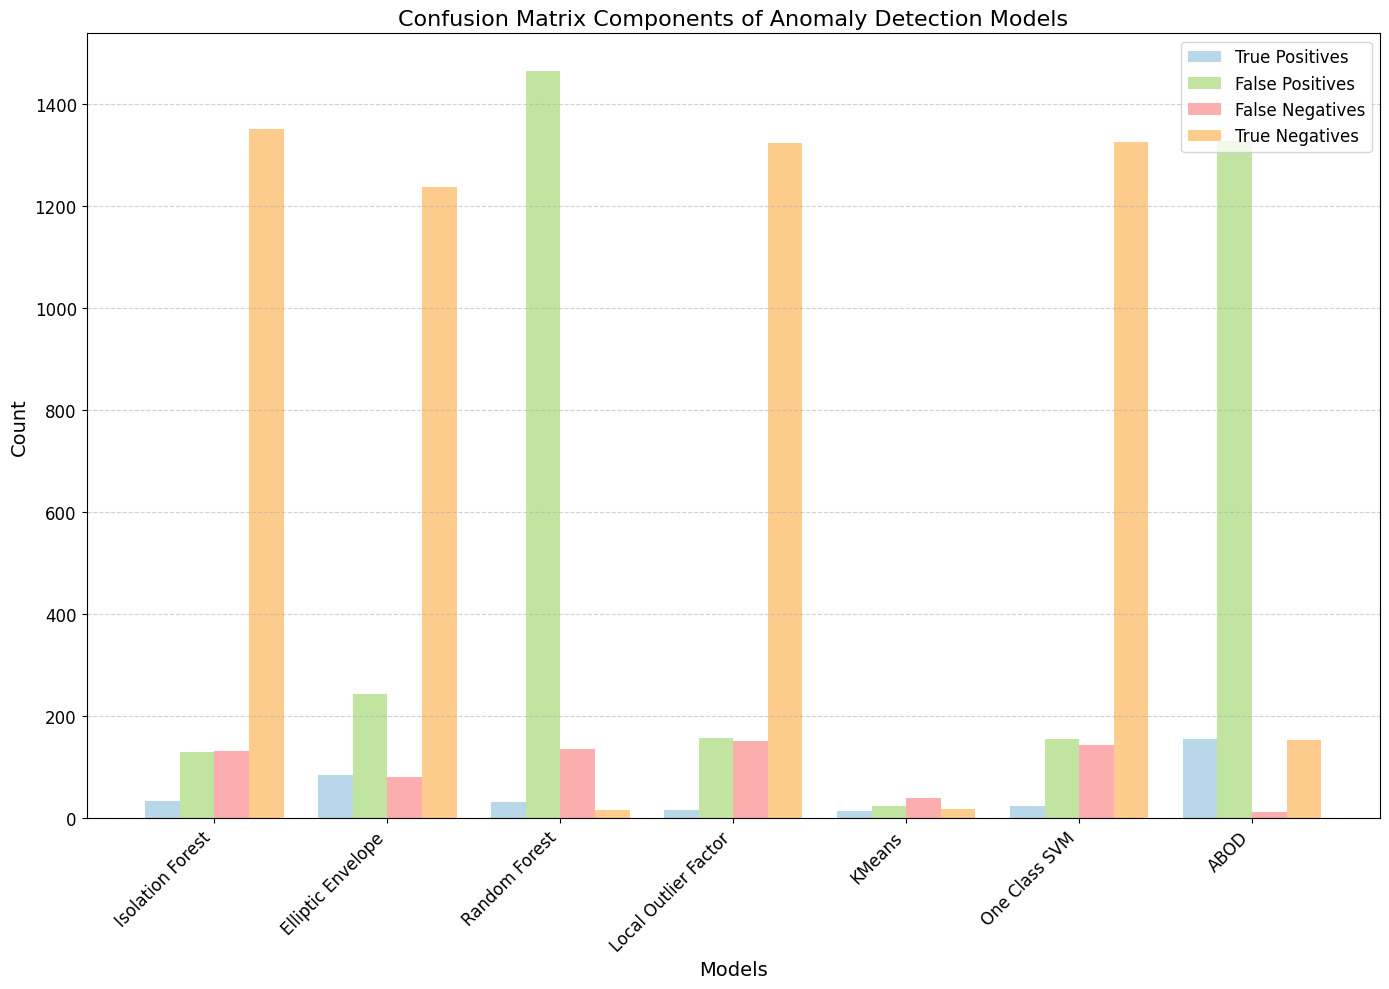

In [7]:
# Create a bar plot for confusion matrix metrics
plt.figure(figsize=(14, 10))

plt.bar(index, tp_scores, width=bar_width, label='True Positives', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], fp_scores, width=bar_width, label='False Positives', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], fn_scores, width=bar_width, label='False Negatives', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], tn_scores, width=bar_width, label='True Negatives', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Confusion Matrix Components of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

New results with much more data:
CHFDO00D_Shared_Benchmark_Q2_DE_2024, 11813 samples (od kojih anomalije 492), dates: 24.04., 25.04., 8.05., 10.05., 14.05., 26.05., 27.05.;
CHFDO00G_Q2_BM_CH_2024, 4692 samples (od kojih anomalije 658), dates: 15.05. - 18.05.;
Z0299577_Q2_AT_2024, 1503 samples (od kojih anomalije 26), dates: 18.05.;
XYZ12345_1und1_Q2_DE_2024_Extension, 7285 samples (od kojih anomalije 111), dates: 8.05., 24.05. - 27.05.;
CHFDO00J_Shared_Benchmark_Q2_NL_2024, 7513 samples (od kojih anomalije 410), dates: 10.05., 13.05.;
Ukupno: 43551 (41854/1697) =4%

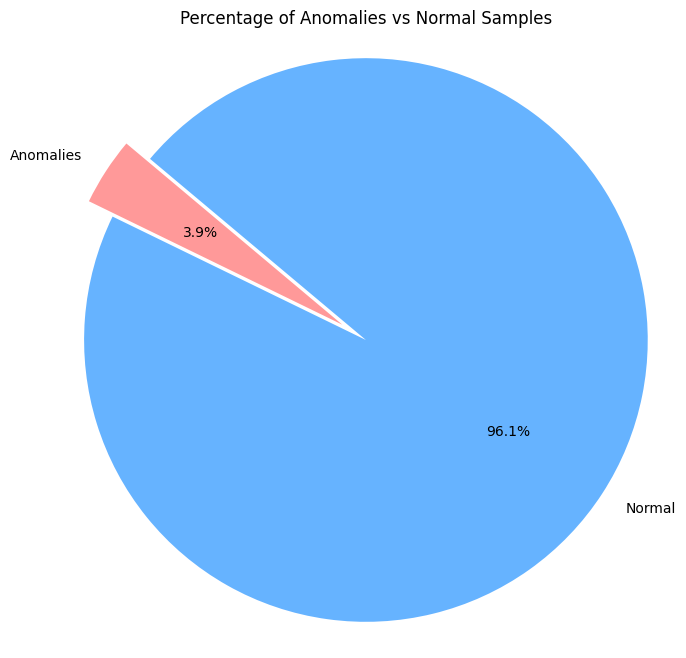

In [8]:
# Define the numbers
anomalies = 1697
normal_samples = 41854
total_samples = anomalies + normal_samples

# Calculate the percentages
anomaly_percentage = (anomalies / total_samples) * 100
normal_percentage = (normal_samples / total_samples) * 100

# Create the pie chart
labels = ['Anomalies', 'Normal']
sizes = [anomaly_percentage, normal_percentage]
colors = ['#ff9999', '#66b3ff']  # Red for anomalies, Blue for normal
explode = (0.1, 0)  # Explode the first slice (Anomalies)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

plt.title('Percentage of Anomalies vs Normal Samples')
plt.show()

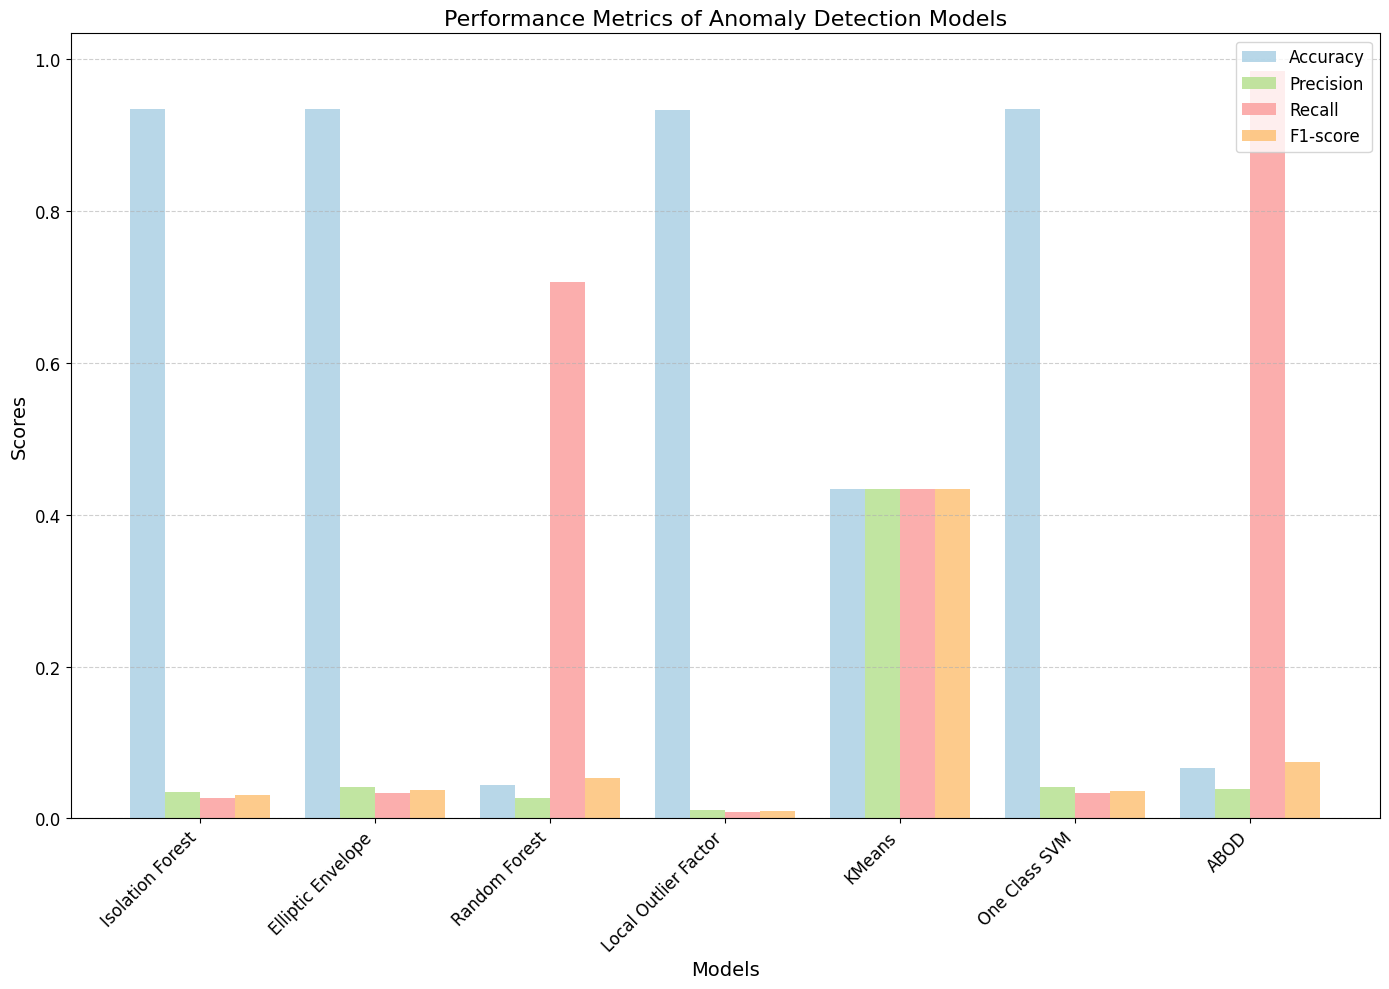

In [7]:
# Define the model names and corresponding evaluation metrics
model_names = ["Isolation Forest", "Elliptic Envelope", "Random Forest", "Local Outlier Factor", "KMeans", "One Class SVM", "ABOD"]

# Updated metrics from the results provided
accuracy_scores = [0.9341, 0.9346, 0.0435, 0.9327, 0.4339, 0.9338, 0.0668]
precision_scores = [0.0344, 0.0420, 0.0275, 0.0115, 0.4339, 0.0409, 0.0385]
recall_scores = [0.0273, 0.0333, 0.7061, 0.0091, 0.4339, 0.0333, 0.9848]
f1_scores = [0.0304, 0.0372, 0.0530, 0.0101, 0.4339, 0.0367, 0.0740]

# Confusion matrix values
confusion_matrices = [
    [8128, 253, 321, 9],    # Isolation Forest
    [8130, 251, 319, 11],   # Elliptic Envelope
    [146, 8235, 97, 233],   # Random Forest
    [8122, 259, 327, 3],    # Local Outlier Factor
    [3558, 4823, 108, 222], # KMeans
    [8123, 258, 319, 11],   # One Class SVM
    [257, 8124, 5, 325]     # ABOD
]

# Extract TP, FP, FN, TN for visualization
tp_scores = [cm[3] for cm in confusion_matrices]
fp_scores = [cm[1] for cm in confusion_matrices]
fn_scores = [cm[2] for cm in confusion_matrices]
tn_scores = [cm[0] for cm in confusion_matrices]

# Set a color palette
colors = sns.color_palette("Paired")

# Create a bar plot for performance metrics
plt.figure(figsize=(14, 10))

# Plotting each metric separately for better visualization
bar_width = 0.2
index = range(len(model_names))

plt.bar(index, accuracy_scores, width=bar_width, label='Accuracy', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], precision_scores, width=bar_width, label='Precision', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], recall_scores, width=bar_width, label='Recall', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], f1_scores, width=bar_width, label='F1-score', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Scores', fontsize=14)
plt.title('Performance Metrics of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

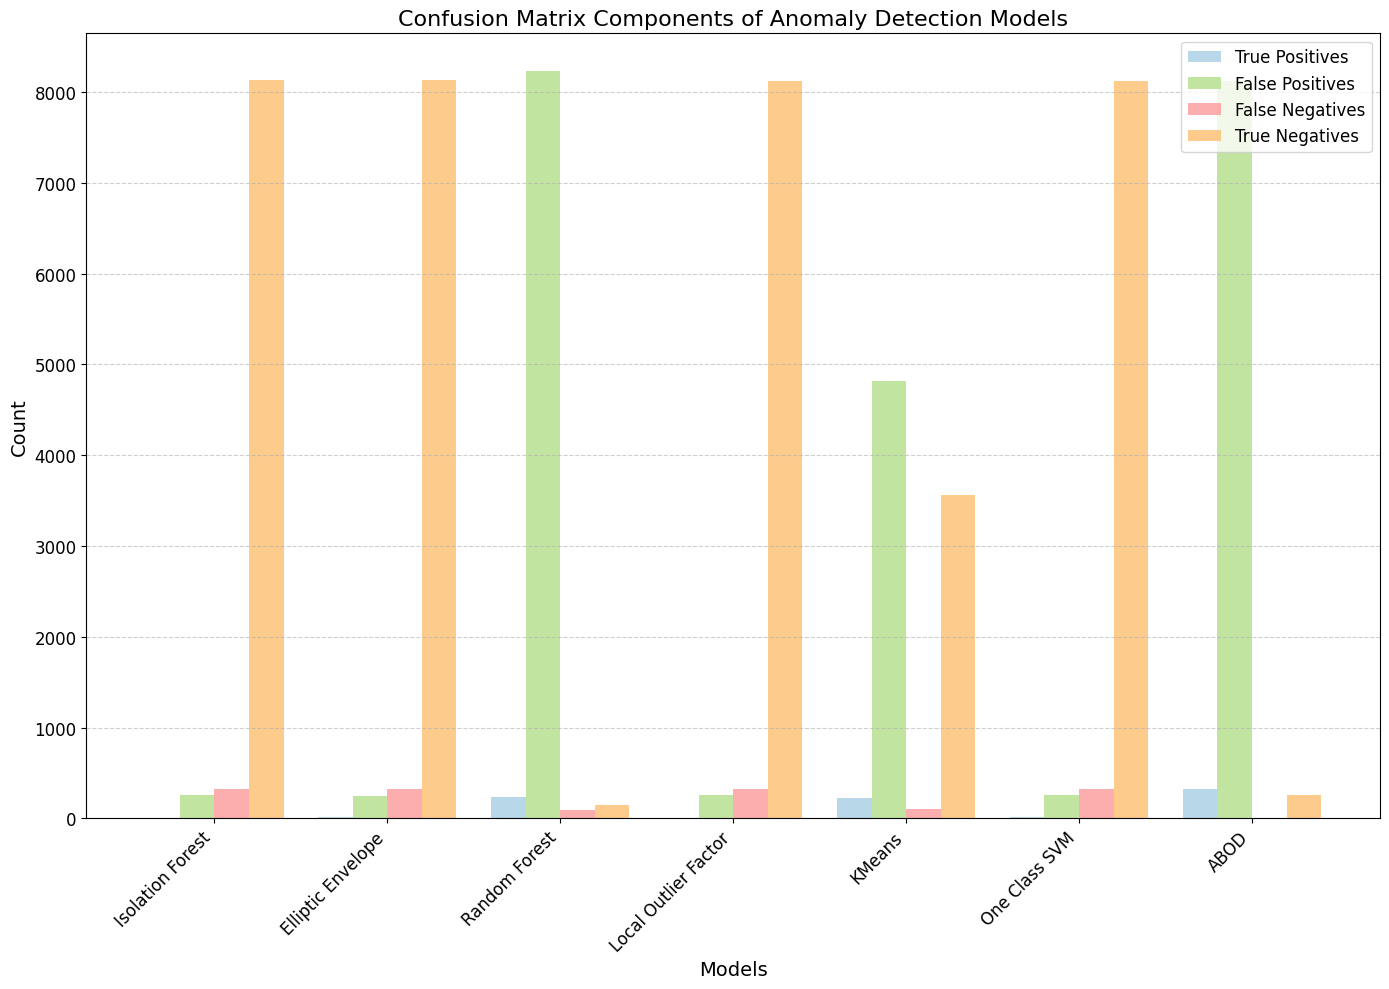

In [4]:
# Create a bar plot for confusion matrix metrics
plt.figure(figsize=(14, 10))

plt.bar(index, tp_scores, width=bar_width, label='True Positives', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], fp_scores, width=bar_width, label='False Positives', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], fn_scores, width=bar_width, label='False Negatives', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], tn_scores, width=bar_width, label='True Negatives', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Confusion Matrix Components of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

The things that were changed for these results to be like this: contamination to be 3% since thats the ratio - the desired ratio would be 1% of contamiination maybe. Number of branching for isolation andn random forest to be 1000 and 5000; AND for ABOD number of neighbors is 50.

here i had an idea

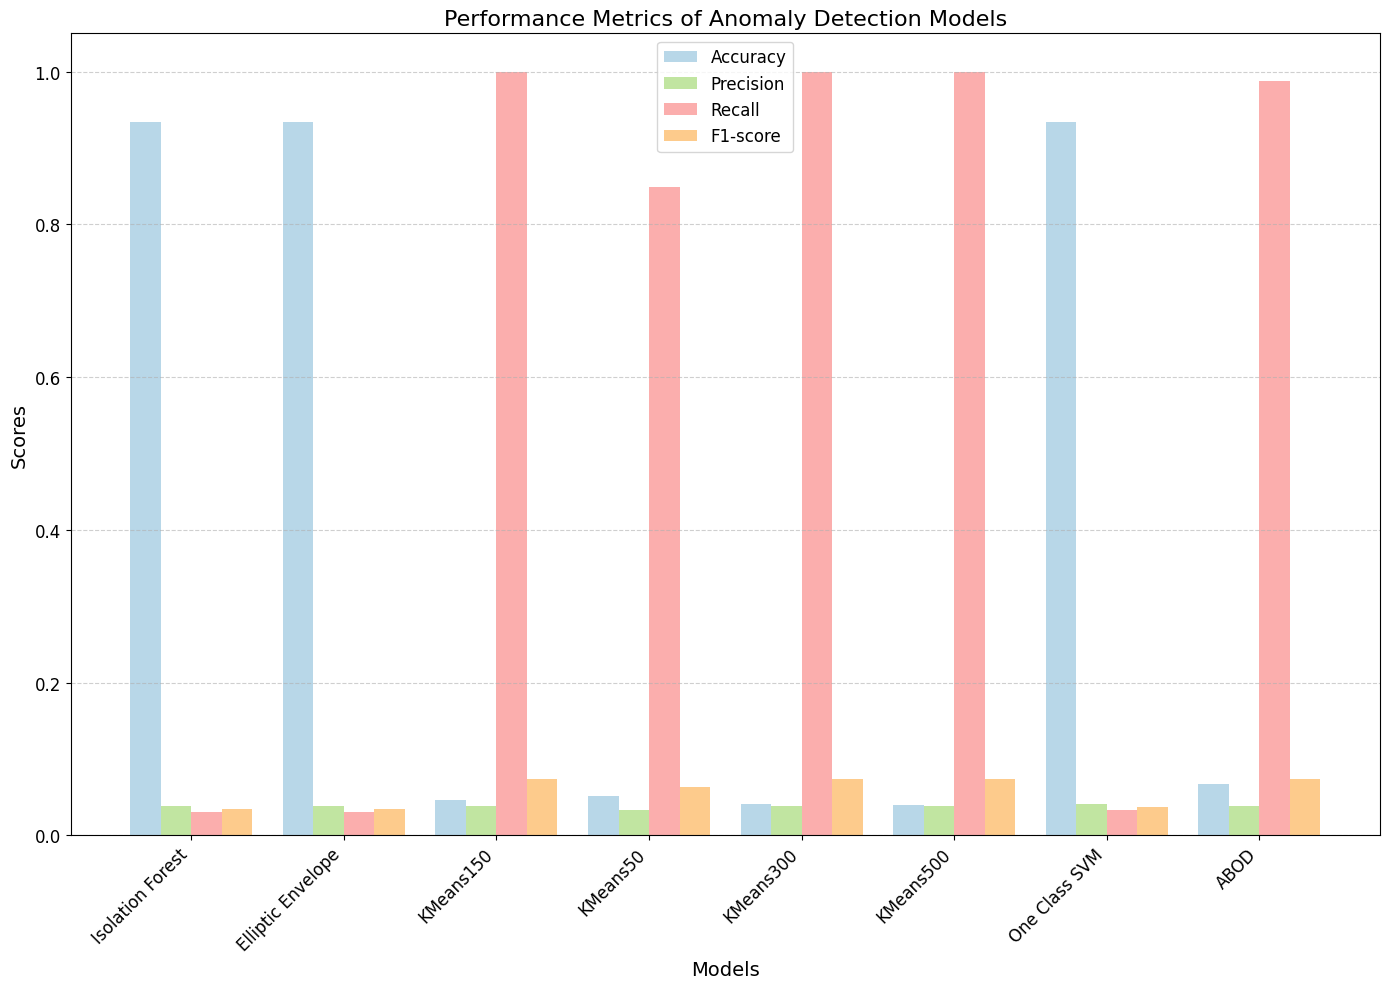

In [9]:
# Define the model names and corresponding evaluation metrics
model_names = ["Isolation Forest", "Elliptic Envelope", "KMeans150", "KMeans50", "KMeans300", "KMeans500", "One Class SVM", "ABOD"]

# Updated metrics from the results provided
accuracy_scores = [0.9343, 0.9343, 0.0459, 0.0520, 0.0411, 0.0399, 0.9338, 0.0670]
precision_scores = [0.0382, 0.0382, 0.0382, 0.0330, 0.0380, 0.0380, 0.0409, 0.0386]
recall_scores = [0.0303, 0.0303, 1.0000, 0.8485, 1.0000, 1.0000, 0.0333, 0.9879]
f1_scores = [0.0338, 0.0338, 0.0736, 0.0635, 0.0732, 0.0731, 0.0367, 0.0743]

# Confusion matrix values
confusion_matrices = [
    [8129, 252, 320, 10],    # Isolation Forest
    [8129, 252, 320, 10],   # Elliptic Envelope
    [70, 8311, 0, 330],   # KMeans150
    [173, 8208, 50, 280],    # KMeans50
    [28, 8353, 0, 330], # KMeans300
    [18, 8363, 0, 330],   # KMeans500
    [8123, 258, 319, 11],   # One Class SVM
    [258, 8123, 4, 326]     # ABOD
]

# Extract TP, FP, FN, TN for visualization
tp_scores = [cm[3] for cm in confusion_matrices]
fp_scores = [cm[1] for cm in confusion_matrices]
fn_scores = [cm[2] for cm in confusion_matrices]
tn_scores = [cm[0] for cm in confusion_matrices]

# Set a color palette
colors = sns.color_palette("Paired")

# Create a bar plot for performance metrics
plt.figure(figsize=(14, 10))

# Plotting each metric separately for better visualization
bar_width = 0.2
index = range(len(model_names))

plt.bar(index, accuracy_scores, width=bar_width, label='Accuracy', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], precision_scores, width=bar_width, label='Precision', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], recall_scores, width=bar_width, label='Recall', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], f1_scores, width=bar_width, label='F1-score', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Scores', fontsize=14)
plt.title('Performance Metrics of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

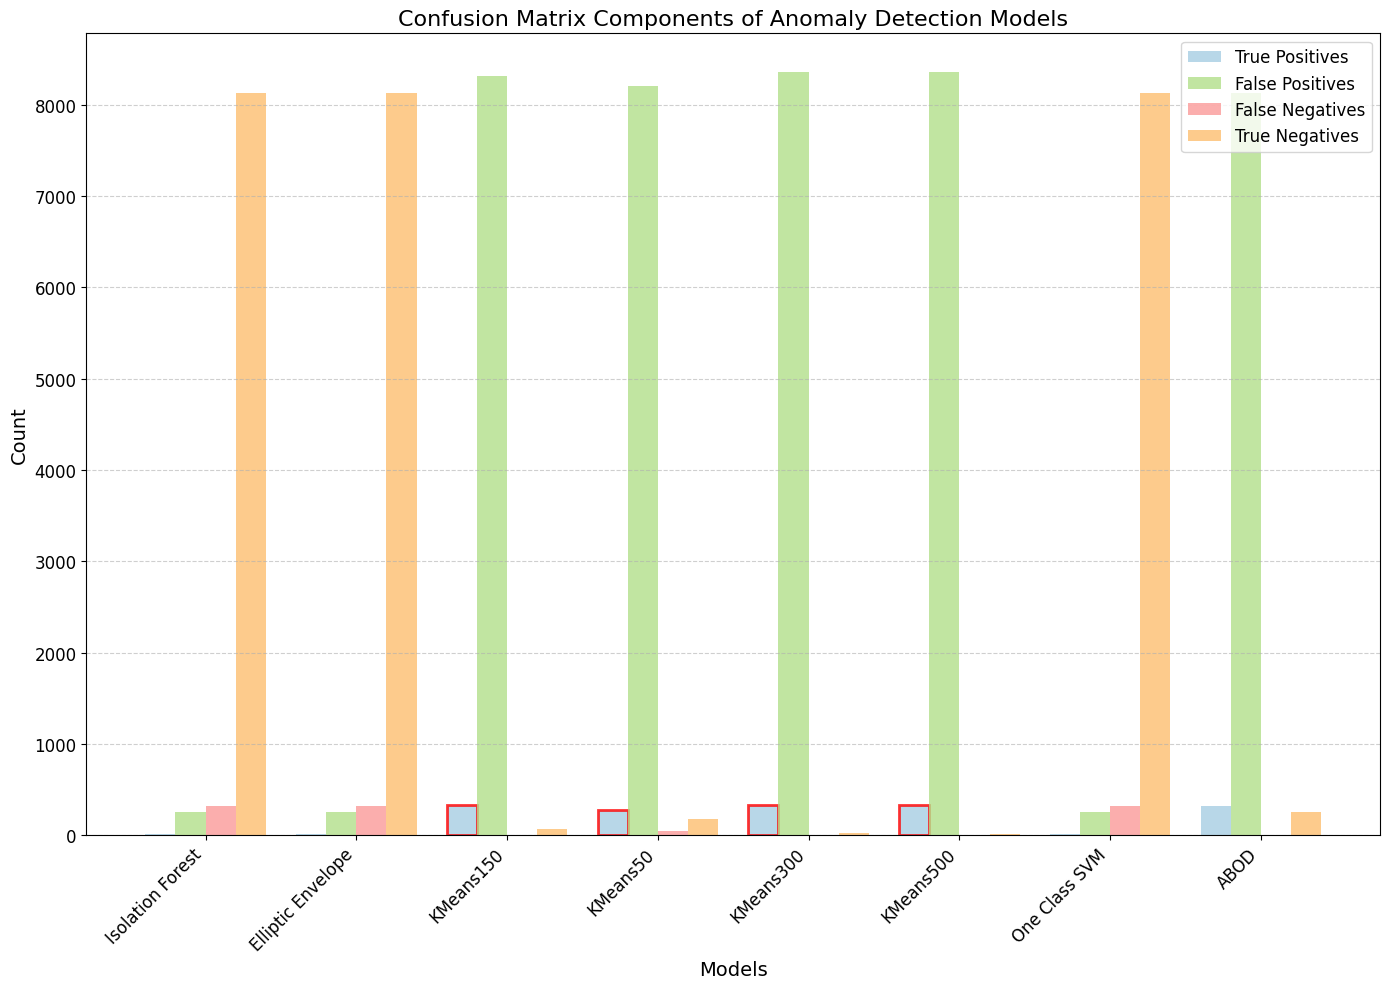

In [10]:
# Create a bar plot for confusion matrix metrics
plt.figure(figsize=(14, 10))

plt.bar(index, tp_scores, width=bar_width, label='True Positives', color=colors[0], alpha=0.8)
plt.bar([i + bar_width for i in index], fp_scores, width=bar_width, label='False Positives', color=colors[2], alpha=0.8)
plt.bar([i + 2 * bar_width for i in index], fn_scores, width=bar_width, label='False Negatives', color=colors[4], alpha=0.8)
plt.bar([i + 3 * bar_width for i in index], tn_scores, width=bar_width, label='True Negatives', color=colors[6], alpha=0.8)

# Add labels and title
plt.xlabel('Models', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Confusion Matrix Components of Anomaly Detection Models', fontsize=16)
plt.xticks([i + 1.5 * bar_width for i in index], model_names, rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Add gridlines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Highlight the sections for ABOD and Random Forest
for i in [2, 3, 4, 5]:
    plt.gca().patches[i].set_edgecolor('red')
    plt.gca().patches[i].set_linewidth(2)

# Show the plot
plt.tight_layout()
plt.show()